In [77]:
import pandas as pd
import krippendorff
from irrCAC.raw import CAC
import seaborn as sns

### Consistency Post Processing

In [162]:
SAMPLE_SIZE = 406
df = pd.read_csv(f'../data/consistency_grades_{SAMPLE_SIZE}_sample.csv')
df = df.drop(columns=['Unnamed: 0'])
df['predictions_0'] = pd.Categorical(df['predictions_0'], ['A++', 'A+', 'A', 'A-', 'B+', 'B', 'B-','C+', 'C', 'C-', 'D+', 'D', 'D-', 'F'], ordered=True)
df['predictions_1'] = pd.Categorical(df['predictions_1'], ['A++', 'A+', 'A', 'A-', 'B+', 'B', 'B-','C+', 'C', 'C-', 'D+', 'D', 'D-', 'F'], ordered=True)
df['predictions_2'] = pd.Categorical(df['predictions_2'], ['A++', 'A+', 'A', 'A-', 'B+', 'B', 'B-','C+', 'C', 'C-', 'D+', 'D', 'D-', 'F'], ordered=True)
df['predictions_3'] = pd.Categorical(df['predictions_3'], ['A++', 'A+', 'A', 'A-', 'B+', 'B', 'B-','C+', 'C', 'C-', 'D+', 'D', 'D-', 'F'], ordered=True)
df.head()

,assignment_number,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3
0,297,Waits for setGraphView to finish and then returns the graphView object.\nThis method is taken and modified from the source mentioned in the class comment.\n\n@return This object of GraphView,public static GraphView waitForGraphView() {\n try {\n latch.await();\n } catch (InterruptedException e) {\n e.printStackTrace();\n }\n return graphView;\n },Waits for setGraphView to finish and then returns the graphView object.\nThis method is taken and modified from the source mentioned in the class comment.\n\n@return This object of GraphView<CODESPLIT>public static GraphView waitForGraphView() {\n try {\n latch.await();\n } catch (InterruptedException e) {\n e.printStackTrace();\n }\n return graphView;\n },D-,D-,D-,D-
1,297,Sets the graphViev and marks the work done.\nThis method is taken and modified from the source mentioned in the class comment.\n\n@param newGraphView The object of GraphView to be set.,public static void setGraphView(GraphView newGraphView) {\n graphView = newGraphView;\n latch.countDown();\n },Sets the graphViev and marks the work done.\nThis method is taken and modified from the source mentioned in the class comment.\n\n@param newGraphView The object of GraphView to be set.<CODESPLIT>public static void setGraphView(GraphView newGraphView) {\n graphView = newGraphView;\n latch.countDown();\n },D-,D-,D-,D-
2,297,Creates the GridPane and 4 charts. Places the charts into the GridPane and\nshows the stage.\n\n@param stage The stage of the view,"@Override\n public void start(Stage stage) {\n stage.setTitle(""Graphs"");\n GridPane root = new GridPane();\n\n createPopulationLineChart();\n createVirusLineChart();\n createPlantLineChart();\n createWeatherLineChart();\n\n GridPane.setConstraints(populationLineChart, 0, 0);\n GridPane.setConstraints(virusLineChart, 1, 0);\n GridPane.setConstraints(plantLineChart, 0, 1);\n GridPane.setConstraints(weatherLineChart, 1, 1);\n root.getChildren().addAll(populationLineChart, virusLineChart, plantLineChart, weatherLineChart);\n\n Scene scene = new Scene(root);\n stage.setScene(scene);\n stage.show();\n }","Creates the GridPane and 4 charts. Places the charts into the GridPane and\nshows the stage.\n\n@param stage The stage of the view<CODESPLIT>@Override\n public void start(Stage stage) {\n stage.setTitle(""Graphs"");\n GridPane root = new GridPane();\n\n createPopulationLineChart();\n createVirusLineChart();\n createPlantLineChart();\n createWeatherLineChart();\n\n GridPane.setConstraints(populationLineChart, 0, 0);\n GridPane.setConstraints(virusLineChart, 1, 0);\n GridPane.setConstraints(plantLineChart, 0, 1);\n GridPane.setConstraints(weatherLineChart, 1, 1);\n root.getChildren().addAll(populationLineChart, virusLineChart, plantLineChart, weatherLineChart);\n\n Scene scene = new Scene(root);\n stage.setScene(scene);\n stage.show();\n }",NaN,NaN,NaN,NaN
3,297,"Creates the Animal Population line chart, sets up the x,y Axis. Creates the\nspieces specific population chart series and sets their names. Then the\npopulation chart series are added to the population line chart","public void createPopulationLineChart() {\n // create the x,y Axis\n final NumberAxis xAxisPopulation = new NumberAxis();\n final NumberAxis yAxisPopulation = new NumberAxis();\n xAxisPopulation.setLabel(""Number of Steps"");\n yAxisPopulation.setLabel(""Number of Animals"");\n\n // create the chart\n populationLineChart = new LineChart<Number, Number>(xAxisPopulation, yAxisPopulation);\n populationLineChart.setPrefSize(850, 550);\n populationLineChart.setTitle(""Animal Population"");\n\n // create the animal specific chart series\n mousePopulation = new XYChart.Series();\n sheepPopulation = new XYChart.Series();\n deerPopulation = new XYChart.Series();\n bearPopulation = new XYChart.Series();\n wolfPopulation = new XYChart.Series();\n\n // set the names for the chart series\n mousePopulation.setName(""Mou

In [163]:
df['assignment_number'].unique().shape

(406,)

#### Consistency Calculation per code doc/code pair

In [164]:
def irr_results(df):
    k_df = df[['predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].copy()
    k_df = k_df.dropna()
    k_df['predictions_0'] = k_df['predictions_0'].cat.codes
    k_df['predictions_1'] = k_df['predictions_1'].cat.codes
    k_df['predictions_2'] = k_df['predictions_2'].cat.codes
    k_df['predictions_3'] = k_df['predictions_3'].cat.codes
    k_df = k_df.transpose()

    cac = CAC(k_df.T, 'ordinal')
    ac2 = cac.gwet()['est']['coefficient_value']

    alpha = krippendorff.alpha(k_df.to_numpy(), level_of_measurement='ordinal')

    return f'Krippendorfs Alpha: {alpha}, Gwet Coefficient: {ac2} for SAMPLE size {SAMPLE_SIZE}'

irr_results(df)


'Krippendorfs Alpha: 1.0, Gwet Coefficient: 1.0 for SAMPLE size 406'

In [165]:
df[(df['predictions_0'] != df['predictions_1']) & (df['predictions_1'] != df['predictions_2']) & (df['predictions_2'] != df['predictions_3'])].dropna()

,assignment_number,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3


### Project-Level

In [166]:
def consensus(group):
    consensus_dict = {}
    for grade in group:
        if grade not in consensus_dict:
            consensus_dict[grade] = 1
        else:
            consensus_dict[grade] += 1
    return max(consensus_dict, key=consensus_dict.get)

project_df = df.copy()
project_df = project_df.dropna()
project_df = project_df[['assignment_number', 'predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].groupby('assignment_number').agg(consensus)
project_df.head()

,predictions_0,predictions_1,predictions_2,predictions_3
assignment_number,,,,
0,D-,D-,D-,D-
1,D-,D-,D-,D-
3,D-,D-,D-,D-
4,D-,D-,D-,D-
5,D-,D-,D-,D-


In [167]:
irr_results(project_df)

'Krippendorfs Alpha: 1.0, Gwet Coefficient: 1.0 for SAMPLE size 406'

In [168]:
project_df[(project_df['predictions_0'] != project_df['predictions_1']) & (project_df['predictions_1'] != project_df['predictions_2']) & (project_df['predictions_2'] != project_df['predictions_3'])]

,predictions_0,predictions_1,predictions_2,predictions_3
assignment_number,,,,


### Plots

In [169]:
grey = (187/255, 187/255, 187/255)
darkgreen = (51/255, 117/255, 56/255)
teal = (93/255, 168/255, 153/255)
blue = (148/255, 203/255, 236/255)
yellow = (220/255, 205/255, 125/255)
red = (168/255, 96/255, 93/255)
pale_yellow = (164/255, 168/255, 93/255)
sns.set_theme(style="whitegrid")

#### Ungraded Pairs

In [170]:
ungraded_df = df.copy()
ungraded_df['Graded'] = ungraded_df['predictions_0'].apply(lambda x: 'Ungraded' if x is None else 'Graded')
ungraded_df['Graded'] = ungraded_df['Graded'].fillna('Ungraded')
ungraded_df

,assignment_number,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3,Graded
0,297,Waits for setGraphView to finish and then returns the graphView object.\nThis method is taken and modified from the source mentioned in the class comment.\n\n@return This object of GraphView,public static GraphView waitForGraphView() {\n try {\n latch.await();\n } catch (InterruptedException e) {\n e.printStackTrace();\n }\n return graphView;\n },Waits for setGraphView to finish and then returns the graphView object.\nThis method is taken and modified from the source mentioned in the class comment.\n\n@return This object of GraphView<CODESPLIT>public static GraphView waitForGraphView() {\n try {\n latch.await();\n } catch (InterruptedException e) {\n e.printStackTrace();\n }\n return graphView;\n },D-,D-,D-,D-,Graded
1,297,Sets the graphViev and marks the work done.\nThis method is taken and modified from the source mentioned in the class comment.\n\n@param newGraphView The object of GraphView to be set.,public static void setGraphView(GraphView newGraphView) {\n graphView = newGraphView;\n latch.countDown();\n },Sets the graphViev and marks the work done.\nThis method is taken and modified from the source mentioned in the class comment.\n\n@param newGraphView The object of GraphView to be set.<CODESPLIT>public static void setGraphView(GraphView newGraphView) {\n graphView = newGraphView;\n latch.countDown();\n },D-,D-,D-,D-,Graded
2,297,Creates the GridPane and 4 charts. Places the charts into the GridPane and\nshows the stage.\n\n@param stage The stage of the view,"@Override\n public void start(Stage stage) {\n stage.setTitle(""Graphs"");\n GridPane root = new GridPane();\n\n createPopulationLineChart();\n createVirusLineChart();\n createPlantLineChart();\n createWeatherLineChart();\n\n GridPane.setConstraints(populationLineChart, 0, 0);\n GridPane.setConstraints(virusLineChart, 1, 0);\n GridPane.setConstraints(plantLineChart, 0, 1);\n GridPane.setConstraints(weatherLineChart, 1, 1);\n root.getChildren().addAll(populationLineChart, virusLineChart, plantLineChart, weatherLineChart);\n\n Scene scene = new Scene(root);\n stage.setScene(scene);\n stage.show();\n }","Creates the GridPane and 4 charts. Places the charts into the GridPane and\nshows the stage.\n\n@param stage The stage of the view<CODESPLIT>@Override\n public void start(Stage stage) {\n stage.setTitle(""Graphs"");\n GridPane root = new GridPane();\n\n createPopulationLineChart();\n createVirusLineChart();\n createPlantLineChart();\n createWeatherLineChart();\n\n GridPane.setConstraints(populationLineChart, 0, 0);\n GridPane.setConstraints(virusLineChart, 1, 0);\n GridPane.setConstraints(plantLineChart, 0, 1);\n GridPane.setConstraints(weatherLineChart, 1, 1);\n root.getChildren().addAll(populationLineChart, virusLineChart, plantLineChart, weatherLineChart);\n\n Scene scene = new Scene(root);\n stage.setScene(scene);\n stage.show();\n }",NaN,NaN,NaN,NaN,Ungraded
3,297,"Creates the Animal Population line chart, sets up the x,y Axis. Creates the\nspieces specific population chart series and sets their names. Then the\npopulation chart series are added to the population line chart","public void createPopulationLineChart() {\n // create the x,y Axis\n final NumberAxis xAxisPopulation = new NumberAxis();\n final NumberAxis yAxisPopulation = new NumberAxis();\n xAxisPopulation.setLabel(""Number of Steps"");\n yAxisPopulation.setLabel(""Number of Animals"");\n\n // create the chart\n populationLineChart = new LineChart<Number, Number>(xAxisPopulation, yAxisPopulation);\n populationLineChart.setPrefSize(850, 550);\n populationLineChart.setTitle(""Animal Population"");\n\n // create the animal specific chart series\n mousePopulation = new XYChart.Series();\n sheepPopulation = new XYChart.Series();\n deerPopulation = new XYChart.Series();\n bearPopulation = new XYChart.Series();\n wolfPopulation = new XYChart.Series();\n\n // set the names for the chart series\n

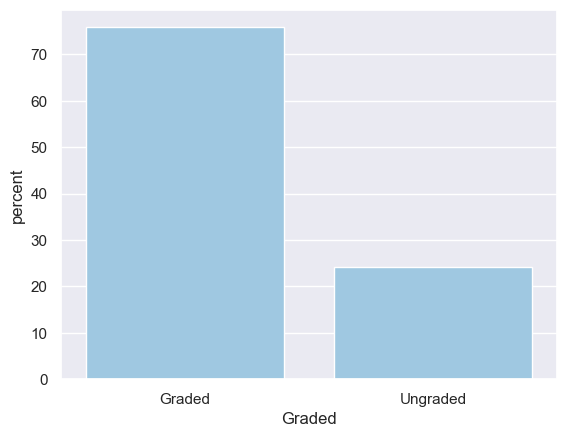

In [160]:
g = sns.countplot(ungraded_df, x='Graded', stat='percent', color=blue)
g.get_figure().savefig(f'plots/ungraded_counts_{SAMPLE_SIZE}.pdf', bbox_inches='tight')

In [171]:
ungraded_df[ungraded_df['Graded'] == 'Ungraded']['text'].apply(lambda x: len(x)).min()
# Max token length of CodeBERT is 512

512

### Project Grade Plot

<Axes: xlabel='predictions_0', ylabel='assignment_number'>

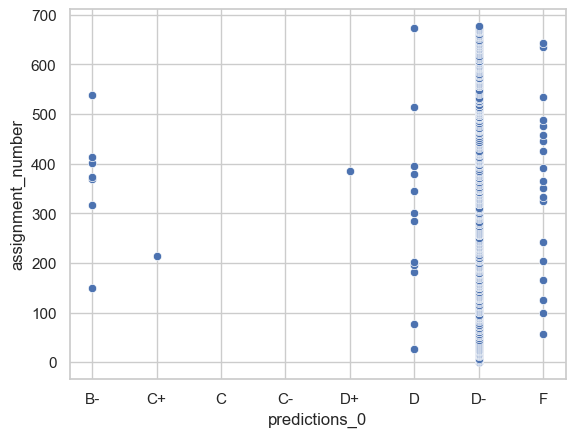

In [173]:
# TODO: Plot of x-assignment number, y - grade, hue - prediction iteration
project_plot_df = project_df.copy().reset_index()
project_plot_df['assignment_number'] = pd.Categorical(project_plot_df['assignment_number'])
project_plot_df

sns.scatterplot(project_df, y='assignment_number', x='predictions_0')